# Assignment 1

AI-Machine Learning Foundations

Candela X. Muñoz

March 4th 2026

https://github.com/cxmunozieu2024/ML-fundamentals-2026

## Step 1: Identifying prediction target

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.dummy import DummyClassifier

In [2]:
df = pd.read_csv("bank-additional.csv", sep = ";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [4]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

The target variable is "y", which indicates whether a client subscribed to a term deposit or no. The objective is to predict subscription at the time of the contract.

The target is binary: "yes" means they are subscribed, "no" means they are not.

Moreover, the target variable is imbalanced; approximately 89% of clients did not subscribe, while 11% did. This means three important things for us:

1. Accuracy may be misleading, as predicting "no" for all observations would already achieve 89% accuracy.

2. We will need stratified splitting to preserve the class proportion.

3. Class imbalance has to be considered when we interpret metrics such as precision and recall.

## Step 2: Data loading and exploration

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


4119 observations; sample size large enough to train and validate our model.

Note that the pdays mean is overly large (960); we will interpret this soon.

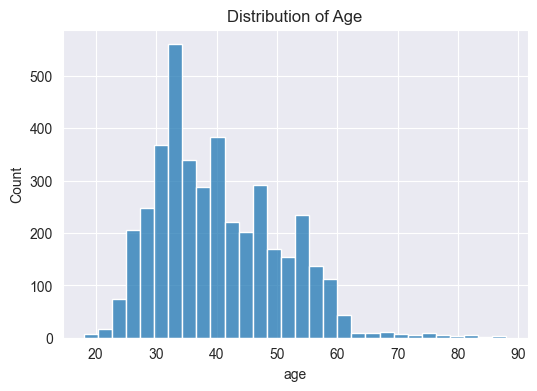

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=30)
plt.title("Distribution of Age")
plt.show()

Age seems to be moderately distributed among working-age individuals.

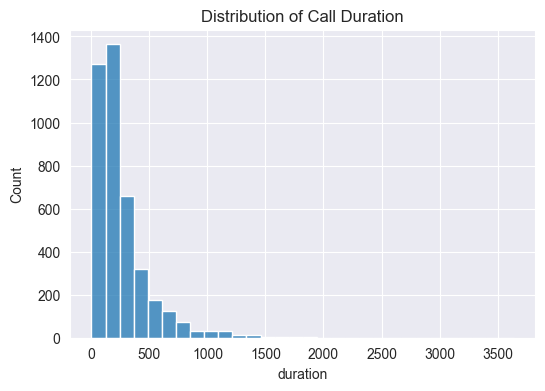

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["duration"], bins=30)
plt.title("Distribution of Call Duration")
plt.show()

### Problem: Call duration

Call duration shows a right-skewed distribution, with most calls being short and a small number being very long. It seems like it must have predictive power. The problem with duration is that it's only measured after the call has ended; our prediction task is to estimate subscription at the time of contact, and the call duration would not be available at this time.

This is a very clear example of temporal data leakage, as duration implicitly contains information about the outcome. We will have to remove it before modelling. 

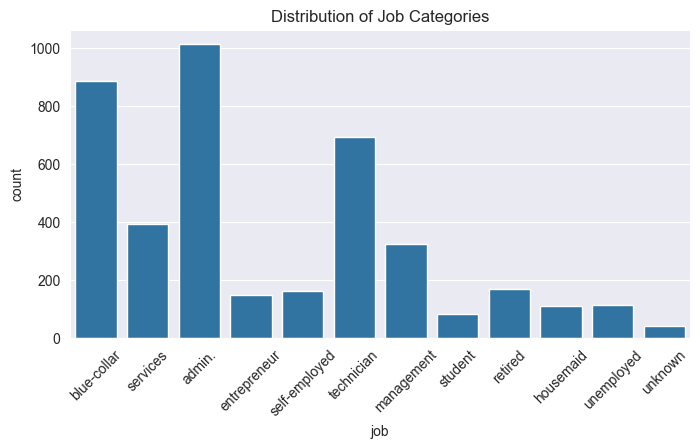

In [8]:
plt.figure(figsize=(8,4))
sns.countplot(x="job", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Job Categories")
plt.show()

The dataset contains various job categories that seem moderately balanced.

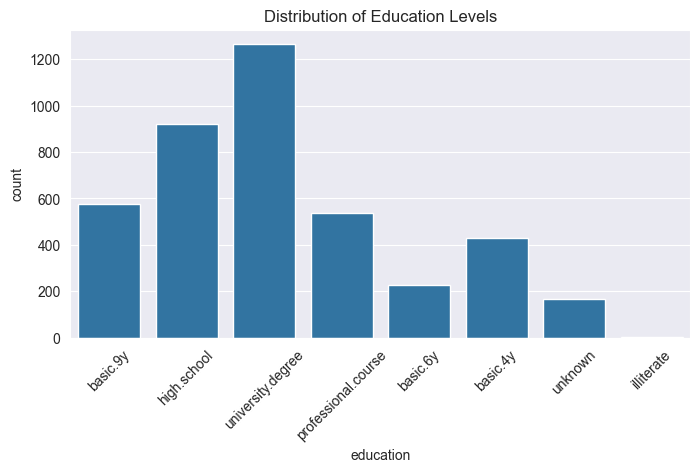

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x="education", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Education Levels")
plt.show()

### To be taken into account: Education

The graph confirms the pressence of "Unknown" values that we will have to deal with accordingly later. We also notice that there is a category with 0 values: "illiterate". Although the category theoretically exists, it is not represented in our sample, so we will need to take it into account when we do the encoding to avoid creating a meaningless feature. We will not remove it for now since we are still in EDA, but it might be problematic in the future if we don't take this into account.

In [10]:
df["pdays"].describe()
df["pdays"].value_counts().head()

pdays
999    3959
3        52
6        42
4        14
7        10
Name: count, dtype: int64

### To be taken into account: Pdays

This variable represents the n of days since the customer was last contacted. However, the value 999 appears very often and it doesn't represent a normal number of days; instead it means that the client was never contacted before. If we treat 999 as a continuous numerical value we would significantly distort scaling and modelling; we will have to transform it (we could convert it into a separate binary indicator or replace it with NaN and handle it explicitly).

In [11]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [12]:
(df == "unknown").sum()

age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

### Implicit missing values

There are no explicit NaN values, however several categorical variables contain the value "unkown", which still represents implicit missing information.

The variable "default" contains a particularly high number of "unknown" entries which might significantly affect modeling decisions.

These "unknown" values need special treatment; they cannot be treated as a regular category because it may introduce bias.

In [13]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

### Variable classification

Based on the dataset structure, the numerical variables are: age, duration, campaign, pdays, previous, emp.var.rate, cons.price,idx, cons.conf.idx, euribor3m and nr.employed.

The categorical nominal variables are: job, marital, default, housing, loan, contact, month, day_of_week and poutcome.

Finally, education is categorical but not nominal; it's ordinal because it has rank structure. It will need a different type of encoding later.

## Step 3: Data splitting

In [14]:
df["y"] = df["y"].map({"no": 0, "yes": 1})
df["y"].value_counts()

y
0    3668
1     451
Name: count, dtype: int64

We convert the target variable to binary format (0 = client did not subscribe; 1 = client subscribed) because we need it for Logistic Regression. We do it before splitting.

In [15]:
X = df.drop("y", axis=1)
y = df["y"]
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42)

In [16]:
print("Train size:", X_train.shape) #Check that we made the split correctly
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (2471, 20)
Validation size: (824, 20)
Test size: (824, 20)


In [17]:
print("Train distribution:", y_train.value_counts(normalize=True)) #We check the target var proportions in each subset
print("Validation distribution:", y_val.value_counts(normalize=True))
print("Test distribution:", y_test.value_counts(normalize=True))

Train distribution: y
0    0.890328
1    0.109672
Name: proportion, dtype: float64
Validation distribution: y
0    0.890777
1    0.109223
Name: proportion, dtype: float64
Test distribution: y
0    0.890777
1    0.109223
Name: proportion, dtype: float64


### Splitting strategy justification

We split the dataset into training (60%), validation (20%) and test (20%). We applied strattified splitting to preserve the class distribution of the target variable across all three subsets (we had to do this because of the class imbalance 89-11). We perform splitting before any preprocessing steps to avoid data leakage.

## Step 4: Handling missing values

We remember that we had 0 NaN values but many unknown values across several variables.

In [18]:
X_train = X_train.drop("duration", axis=1)
X_val = X_val.drop("duration", axis=1)
X_test = X_test.drop("duration", axis=1)

Firstly, we remove the problematic "duration" variable that would have caused data leakage, as mentioned earlier.

In [19]:
for dataset in [X_train, X_val, X_test]:
    dataset["previously_contacted"] = dataset["pdays"].apply(lambda x: 0 if x == 999 else 1)
    dataset["pdays"] = dataset["pdays"].replace(999, 0)

Then, we deal with pdays: the 999 values are transformed into a new binary variable, "previously_contacted", which can be 0 (no) or 1 (yes). The original pdays keeps all values that weren't 999 and transforms the 999 to 0.

We will not remove the "unknown" values, to allow the model to learn whether missingness itself might carry important information.

In [20]:
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
2502,52,services,married,high.school,no,yes,no,cellular,aug,tue,5,0,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
182,51,technician,married,unknown,no,yes,no,telephone,jun,fri,3,0,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
1381,50,services,married,high.school,no,yes,no,cellular,aug,mon,15,0,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,0
202,42,self-employed,married,university.degree,no,yes,no,cellular,nov,fri,3,0,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
147,40,technician,married,basic.9y,unknown,no,yes,telephone,may,thu,4,0,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0


We can now see that the duration variable is gone, pdays is no longer 999 and previously_contacted appears as a new binary variable.

## Step 5: Encoding categorical variables

In [21]:
ordinal_cols = ["education"]
nominal_cols = ["job", "marital", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]

In [22]:
X_train["education"].unique()

<StringArray>
[        'high.school',             'unknown',   'university.degree',
            'basic.9y', 'professional.course',            'basic.4y',
            'basic.6y',          'illiterate']
Length: 8, dtype: str

In [23]:
education_order = {
    "illiterate": 0,
    "basic.4y": 1,
    "basic.6y": 2,
    "basic.9y": 3,
    "high.school": 4,
    "professional.course": 5,
    "university.degree": 6,
    "unknown": -1
}

for dataset in [X_train, X_val, X_test]:
    dataset["education"] = dataset["education"].map(education_order)

We use ordinal encoding for the education variable, since it contains a ranking that needs to be reflected. "unkown" was mapped to -1 to keep it and the misingness information it may contain.

In [24]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

ohe.fit(X_train[nominal_cols])

X_train_ohe = ohe.transform(X_train[nominal_cols])
X_val_ohe = ohe.transform(X_val[nominal_cols])
X_test_ohe = ohe.transform(X_test[nominal_cols])

In [25]:
ohe_feature_names = ohe.get_feature_names_out(nominal_cols)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_feature_names, index=X_val.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)

In [26]:
X_train = pd.concat([X_train.drop(nominal_cols, axis=1), X_train_ohe_df], axis=1)
X_val = pd.concat([X_val.drop(nominal_cols, axis=1), X_val_ohe_df], axis=1)
X_test = pd.concat([X_test.drop(nominal_cols, axis=1), X_test_ohe_df], axis=1)

In [27]:
X_train.head()

,age,education,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
2502,52,4,5,0,0,1.4,93.444,-36.1,4.963,5228.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
182,51,-1,3,0,0,1.4,94.465,-41.8,4.959,5228.1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1381,50,4,15,0,0,1.4,93.444,-36.1,4.965,5228.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
202,42,6,3,0,0,-0.1,93.200,-42.0,4.021,5195.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
147,40,3,4,0,0,1.1,93.994,-36.4,4.860,5191.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Encoding strategy justification

Each categorical variable was encoded according to its properties:

Ordinal encoding was used for the "education" variable, to represent its ranking. The "unkown" value was mapped to -1 to preserve the missing value information without inflating the scale.

One-hot encoding was used for all nominal categorical variables, which converts each variable into a binary feature to avoid imposing artificial ordering.

The encoder was fitted on the training set only, and then applied to validation and test sets to prevent data leakage. The parameter "handle_unkown=ignore" is to make sure that unseen categories in these subsets don't cause errors.

Moreover, one-hot encoding allows the model to assign different weights to each category independently, and without it, categorical variables would not be able to be processed by the linear model.

## Step 6: Feature scaling

We need to standardize the values of our features; if one feature goes fom 0-1 and another goes from 0-100, the second one will dominate the gradients, regularization will penalize features unevenly, and coefficients will become hard to interpret.

In [28]:
numeric_cols = ["age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "previously_contacted","education"] #These are our original numerical features

In [29]:
scaler = StandardScaler()

scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [30]:
X_train[numeric_cols].describe().loc[["mean", "std"]]

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,education
mean,-2.020058e-16,5.247837e-17,4.313291e-18,-1.293987e-17,-1.437764e-18,-6.863883e-15,1.680746e-15,1.006434e-16,4.669856e-15,-2.875527e-18,-1.265232e-16
std,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00


### Scaling justification

We separated original numerical variables from the hot-one encoded ones in order to apply z-score normalization to them. This makes the mean of each feature around 0 and its st dev around 1.

We fitted it on the training set first and then we applied it to the other subsets to prevent data leakage.

## Step 7: Feature selection

In [31]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance_mask = selector.get_support()

low_variance_features = X_train.columns[~low_variance_mask]
low_variance_features

Index(['job_unknown', 'marital_unknown', 'month_dec'], dtype='str')

In [32]:
low_variance_cols = ['job_unknown', 'marital_unknown', 'month_dec']

X_train = X_train.drop(columns=low_variance_cols)
X_val = X_val.drop(columns=low_variance_cols)
X_test = X_test.drop(columns=low_variance_cols)

### Removing low variance features

The three one-hot encoded variables "job_unknown", "marital_unknown" and "month_dec" were shown to have very little variance, meaning they were near constant. This means that these categories were extremely rare in our dataset; we removed them because they add very little predictive power and they increase dimensionality unnecessarily. They're not worth keeping.

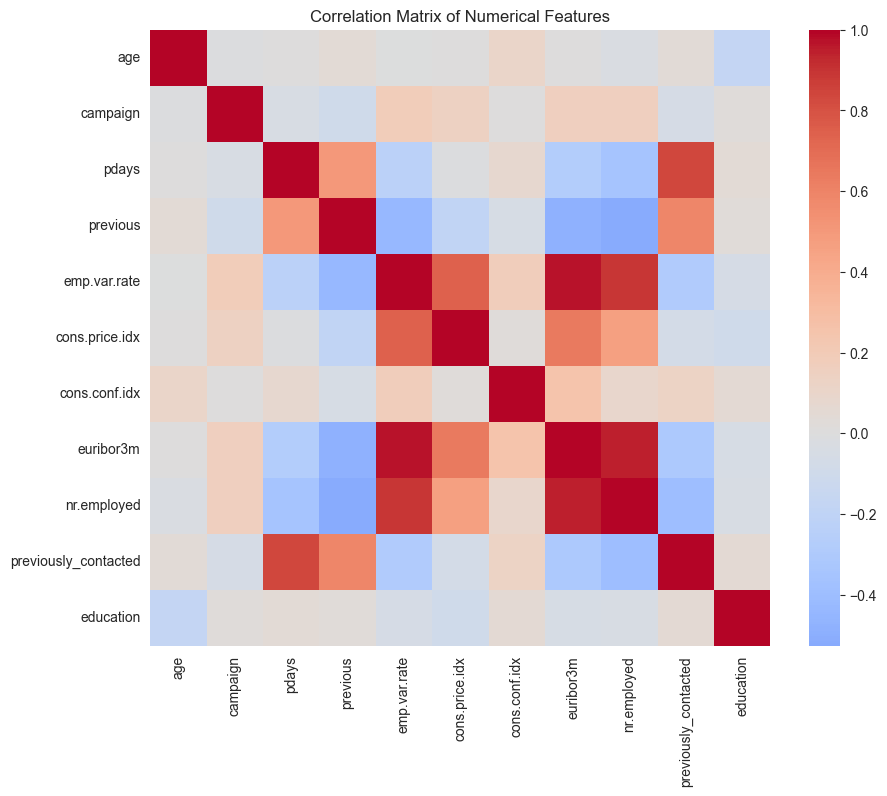

In [33]:
numeric_df = X_train[numeric_cols]

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Multicollinearity

This correlation matrix shows that several economic variables are strongly correlated (>0.8), particularly euribor3m, nr.employed, emp.var.rate and cons.price.idx.

High multicollinearity can destabilize coefficient estimates, reduce interpretability and increase the variance of parameter estimates; however logistic regression with L2 regularization can mitigate the instability by penalizing high correlation between variables. Therefore we will keep them, to preserve predictive information, although we have to acknowledge potential interpretability limitations.

pdays and previously_contacted are naturally correlated because we engineered those features; they will not be a problem.

## Step 8: Addressing class imbalance

In [34]:
y_train.value_counts(normalize=True) #We can see it's (still) 0.89 - 0.11

y
0    0.890328
1    0.109672
Name: proportion, dtype: float64

In [35]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

y_train_resampled.value_counts(normalize=True)

y
0    0.5
1    0.5
Name: proportion, dtype: float64

### SMOTE for class imbalance

The training data showed very strong class imbalance (89-11), so we used SMOTE on the training set. This generates synthetic samples of the minority class by interpolating between nearest neighbors, allowing us to balance the dataset without duplicating observations.

Some important remarks are that SMOTE was applied only to the training set, validation and test sets remain untouched; and, if we had used SMOTE before splitting, we would have introduced data leakage.

SMOTE may have improved class balance but we have to be careful: it has also modified the training distribution and may introduce synthetic noise. We have to take this into account.

## Step 9: Logistic regression model

In [36]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_val_pred = model.predict(X_val)

In [38]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

accuracy, precision, recall

(0.8264563106796117, 0.3374233128834356, 0.6111111111111112)

In [39]:
dummy = DummyClassifier(strategy="most_frequent") #Zero rule baseline
dummy.fit(X_train, y_train)

y_val_dummy = dummy.predict(X_val)

dummy_accuracy = accuracy_score(y_val, y_val_dummy)
dummy_precision = precision_score(y_val, y_val_dummy)
dummy_recall = recall_score(y_val, y_val_dummy)

dummy_accuracy, dummy_precision, dummy_recall #Note the red text doesn't mean there is an ERROR

C:\Users\Usuario\PycharmProjects\OSPC\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8907766990291263, 0.0, 0.0)

### Zero rule baseline and validation performance

Our logistic regression model trained on data balanced with SMOTE achieved 82% accuracy, 34% precision and 61% recall. Compared to the zero rule baseline, the model really improves recall for the minority class. Although overall accuracy decreased, this shows the model's ability to predict the minority class rather than defaulting to majority class. There is a clear tradeoff between imbalance and recall in problems involving class imbalance.

In [40]:
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

test_accuracy, test_precision, test_recall

(0.8276699029126213, 0.3375, 0.6)

### Test set evaluation

On the untouched test set, the model achieved 83% accuracy, 34% precision and 60% recall, which is almost identical to our performance in the validation set. What this means is that there are no signs of overfitting or data leakage, and there's been a proper separation of train, test and validation sets.

### Comparison with zero rule baseline

The zero rule baseline achieved 89% accuracy by always predicting the majority class (not subscribed). However, it achieved 0 recall for the minority class.

Our logistic regression model has lower accuracy (82%), but it successfully identifies around 60% of actual subscribers. So essentially higher accuracy doesn't equal better predictive performance, at least in datasets with such class imbalance.

## Step 10: Task order justification

The order in the steps of the notebook is intentional. We cleaned the data but also avoided data leakage and made sure the evaluation was trustworthy.

### 1. Converting the target variable

We converted the target variable to binary before splitting the dataset. This step only changes how the labels are represented (0 = no, 1 = yes) and does not use any information from the features. Because of that, it does not introduce leakage and is safe to perform at the beginning.

### 2. Splitting before preprocessing

The dataset was split into training (60%), validation (20%), and test (20%) before performing any transformation that learns from the data. This is one of the most important decisions in our pipeline; if we had done any preprocessing steps befpre splitting, the model would be learning from validation and test sets, whcih would make performance look better than it actually is. All transformations that compute statistics were performed only on the training set; the other subsets simulate unseen data.

### 3. Removing duration

The variable duration was removed before modelling because it introduced a clear case of temporal data leakage; call duration is only known after the phone call ends, while our goal is to predict subscription at the time of contact. Keeping it would artificially inflate performance. The removal of the variable wa due to conceptual reasons, not statistical ones.

### 4. Transforming pdays

The value 999 in pdays does not mean that it has been 999 since we last contacted the customer, it means that the customer had never been contacted before. We couldn't treat 999 as a regular number, so we created a binary variable (previously_contacted) and replaced 999 with 0 for those clients who had not been contacted.

### 5. Encoding after splitting

Categorical encoding was done after splitting and fitted only on the training set. education was encoded using ordinal encoding because it has a clear ranking. Nominal variables were encoded using one-hot encoding to avoid imposing an artificial order that doesn't exist in reality.

If encoding had been fitted on the full dataset, validation and test data would influence the structure of the features.

### 6. Scaling after encoding

Scaling was applied only to the original numerical variables (not the one-hot encoded ones). The scaler was fitted on the training set and then applied to validation and test sets. If scaling had been fitted on the entire dataset, the computed mean and standard deviation would include information from validation and test data.

### 7. Removing low-variance features

Low-variance features were identified using the training set only. The three near-constant one-hot variables were removed because they add almost no predictive power and only increase dimensionality. Again, this decision was based exclusively on the training data.

### 8. SMOTE on training data

SMOTE was applied only after splitting and only to the training set. If we had used SMOTE before splitting, synthetic samples derived from the minority class could appear in validation or test sets. That would contaminate evaluation and artificially inflate performance. Validation and test sets were left untouched to keep evaluation realistic.

### 9. Final evaluation

Validation was used to assess model behaviour and make decisions. The test set was used only once at the end. The fact that validation and test results are almost identical confirms that the ordering was correct and that no obvious data leakage occurred. Results were compared to the zero rule baseline according to the project instructions.

### 10. Note about GitHub

I had technical issues with my school laptop so I had to switch to another one where I don't have the Git repository connected. Instead of doing it again, I will upload the Jupyter file manually, I hope it's not a problem; but note I did go through the process in the instructions in my other computer.